  # Uso de redes generativas para la mejora de la señal astronómica



 El presente "notebook" documenta la extracción y emparejamiento de los datos de Gaia y SDSS.



 Puesto que SDSS tiene menos datos con espectrografía que los que proporciona el crossmatch de Gaia, para mostrar los gráficos usaremos un ejemplo aleatorio de SDSS para mostrar la misma espectrometría para ese objeto en Gaia.cÑw



 El procedimiento será el siguiente:

 1. De Gaia, obtener los mejores crossmatches de Gaia y SDSS

 2. De SDSS, obtener la referencia de la tabla de SDSS con la espectrometría (SpecObj)

 3. De SDSS, seleccionar un ejemplo aleatorio

 4. De SDSS, obtener la espectrometría para el ejemplo obtenido en 3.

 5. De Gaia, obtener la espectrometría para el objeto obtenido en 3.

 6. De Gaia y SDSS, mostrar los gráficos para el objecto obtenido en 3

 ## Extracción de los datos

 ### Obtención de una muestra de objetos

  #### Crossmatches Gaia SDSS

  Se seleccionan aleatoriamente los mejores crossmatches entre Gaia y SDSS.

In [26]:
from pathlib import Path
from astroquery.gaia import Gaia
from astropy.table import Table

gaia_query_path = Path("services", "queries", "gaia_sdss_random_subset.adql")
gaia_query_template = gaia_query_path.read_text(encoding="utf-8")
gaia_query = gaia_query_template.format(start_index=30000, end_index=50000)

print(f"Executing Step 1: {gaia_query_path.name}...")
gaia_query_job = Gaia.launch_job_async(gaia_query)
gaia_job_results = gaia_query_job.get_results() or Table()

display(gaia_job_results)


Executing Step 1: gaia_sdss_random_subset.adql...
INFO: Query finished. [astroquery.utils.tap.core]


source_id,ra,dec,phot_bp_mean_mag,phot_rp_mean_mag,original_ext_source_id,angular_distance
,deg,deg,mag,mag,,arcsec
int64,float64,float64,float32,float32,int64,float32
97386635385758976,28.10748363988089,21.85421052784815,14.414324,13.328199,1237679543510630469,0.07904631
150784005274051072,64.78867111871637,26.514776377879635,18.106668,16.98221,1237660554912465548,0.06373736
885974619848414336,110.98305254635041,30.537965683857585,17.198088,16.198103,1237673755504935471,0.083799854
1012764493967581312,138.44081572620522,48.707029416929785,15.907301,14.464811,1237657772316950577,0.05089582
1589762907457297280,228.47946990984158,50.97969443927994,16.189617,15.30423,1237659149387563016,0.067105286
1860881000040702208,307.67481428072153,30.02259250592902,17.369864,15.894102,1237672005304126879,0.042174295
1958150911092920960,334.4817569110048,42.173753956590375,17.30849,16.226406,1237672765505274972,0.048141275
2229421732702064128,335.4800540362377,70.79800730216758,15.858689,14.688266,1237663231224512722,0.025595


  #### SDSS - Datos de referencia de objetos

In [27]:
from astroquery.sdss import SDSS
from astropy.io import ascii
from astropy.table import Table
import services.querying as sq

gaia_crossmatch_ids = gaia_job_results["original_ext_source_id"]
query_filter_ids = ",".join(gaia_crossmatch_ids.astype(str))

sdss_query_path = Path("services", "queries", "sdss.adql")
sdss_query_template = sdss_query_path.read_text(encoding="utf-8")
sdss_query_template_sanitized = sq.sanitize_adql(sdss_query_template)
sdss_query = sdss_query_template_sanitized.format(filter_ids=query_filter_ids)

sdss_query_result = SDSS.query_sql(sdss_query, data_release=13)

display(sdss_query_result)



bestObjID,specObjID,plate,mjd,fiberID,redshift
int64,uint64,int64,int64,int64,float64
1237662300827877635,1887059698834761728,1676,53147,187,1.22274
1237678617434718210,4216670061287313408,3745,55234,636,2.520728
1237656495653847070,3600701101227220992,3198,54865,266,-0.0005022312
1237659149387563016,3712144852314595328,3297,54941,192,-0.000235833


  ### Obtención de los datos de espectrometría

  #### SDSS - Selección ejemplo aleatorio

In [28]:
import random as rnd

sdss_sample_object = rnd.choice(sdss_query_result)

display(sdss_sample_object)


bestObjID,specObjID,plate,mjd,fiberID,redshift
int64,uint64,int64,int64,int64,float64
1237659149387563016,3712144852314595328,3297,54941,192,-0.000235833


 #### SDSS - Espectrometría para el ejemplo

In [29]:

sdss_spectra_response = (
    SDSS.get_spectra(
        plate=sdss_sample_object["plate"],
        mjd=sdss_sample_object["mjd"],
        fiberID=sdss_sample_object["fiberID"],
        data_release=13,
    )
    or []
)

# help(sdss_spectra_response)
# dir(sdss_spectra_response)
# print(sdss_spectra_response)

sdss_fits_file = sdss_spectra_response[0]
sdss_spectra_hdu = sdss_fits_file[
    1
]  # La primera tabla después de la cabecera contiene los datos
sdss_spectra_data = sdss_spectra_hdu.data

display(sdss_spectra_data)


FITS_rec([(105.74431 , 3.5807, 0.07642333, 0, 0, 1.1704825, 2.5241404,  99.24224),
          (112.808   , 3.5808, 0.0692361 , 0, 0, 1.1703658, 2.5430412, 111.55943),
          (117.62454 , 3.5809, 0.06844901, 0, 0, 1.1702526, 2.5745296, 115.79513),
          ...,
          ( 78.44662 , 3.9629, 0.29733   , 0, 0, 0.6325739, 1.8169545,  78.46895),
          ( 79.289825, 3.963 , 0.29568076, 0, 0, 0.6327468, 1.8670871,  78.23285),
          ( 78.146545, 3.9631, 0.2949934 , 0, 0, 0.632919 , 1.9174598,  77.59942)],
         dtype=(numpy.record, [('flux', '>f4'), ('loglam', '>f4'), ('ivar', '>f4'), ('and_mask', '>i4'), ('or_mask', '>i4'), ('wdisp', '>f4'), ('sky', '>f4'), ('model', '>f4')]))

 #### Gaia - Espectrometría para el ejemplo

 Obtenemos la referencia en Gaia para el objecto de muestra de SDSS

In [30]:
gaia_sample_object = gaia_job_results[
    gaia_job_results["original_ext_source_id"] == sdss_sample_object["bestObjID"]
]

display(gaia_sample_object)

gaia_sample_object_source_id = gaia_sample_object["source_id"].item()

display(type(gaia_sample_object_source_id))
display(gaia_sample_object_source_id)


source_id,ra,dec,phot_bp_mean_mag,phot_rp_mean_mag,original_ext_source_id,angular_distance
,deg,deg,mag,mag,,arcsec
int64,float64,float64,float32,float32,int64,float32
1589762907457297280,228.47946990984158,50.97969443927994,16.189617,15.30423,1237659149387563016,0.067105286


int

1589762907457297280

 Y obtenemos la espctrometría para esa referencia.

In [ ]:
import gaiaxpy
import astropy.units as u
from specutils import Spectrum

# 1. Calibrate functionally using gaiaxpy
source_ids = [gaia_sample_object_source_id]
calibrated_spectra, sampling_grid = gaiaxpy.calibrate(source_ids)
gaiaxpy.

# 2. Extract arrays and attach Astropy units
flux_array = calibrated_spectra["flux"].iloc[0]
wavelength_qty = sampling_grid * u.nm
flux_qty = flux_array * (u.W / (u.m**2 * u.nm))

# 3. Instantiate the standard specutils Spectrum1D object
gaia_object_spectrum = Spectrum(flux=flux_qty, spectral_axis=wavelength_qty)

display(gaia_object_spectrum)


In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


<Spectrum(flux=[1.2787547199471414e-17 ... 5.819671175169701e-18] W / (nm m2) (shape=(343,), mean=0.00000 W / (nm m2)); spectral_axis=<SpectralAxis [ 336.  338.  340. ... 1016. 1018. 1020.] nm> (length=343))>

 ### Gráficos comparativos

 #### SDSS - Flujo y Longitud de Onda para una objeto

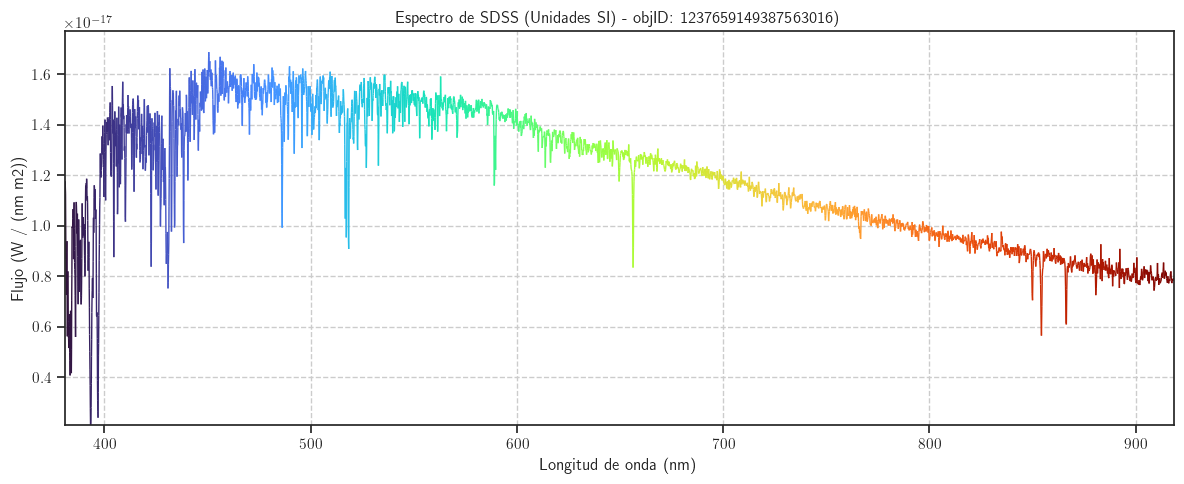

In [32]:
from services.sdss import parse_to_si
from services.plotting import plot_physical_spectrum

wavelength = sdss_spectra_data["loglam"]
flux = sdss_spectra_data["flux"]

sdss_spectrum_si = parse_to_si(wavelength, flux)

plot_physical_spectrum(
    spectrum=sdss_spectrum_si,
    title=f"Espectro de SDSS (Unidades SI) - objID: {sdss_sample_object['bestObjID']})",
)


 #### Gaia - Flujo y Longitud de Onda para una objeto

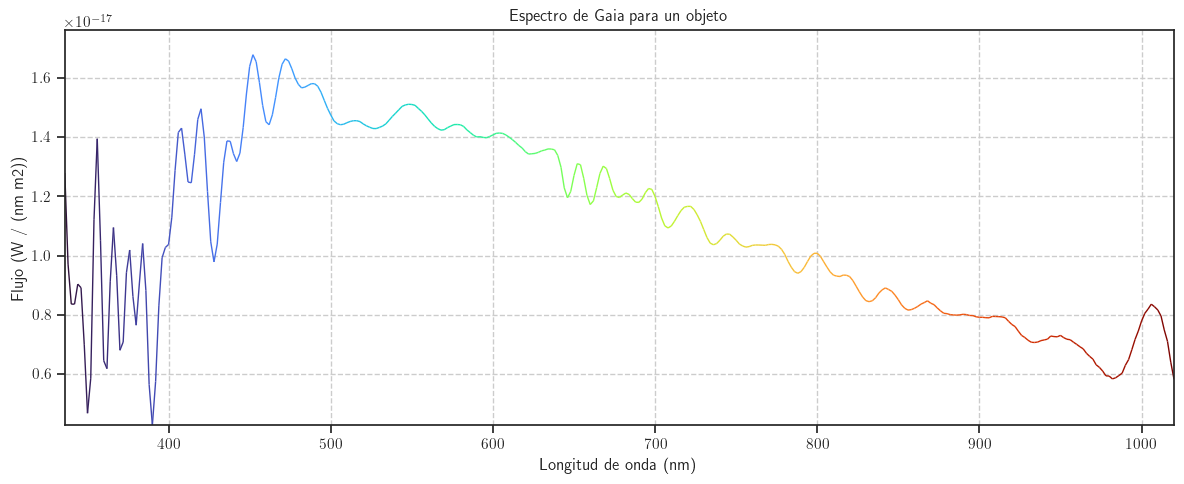

In [33]:
import services.plotting as spl
from specutils import Spectrum
import astropy.units as u

spl.plot_physical_spectrum(
    spectrum=gaia_object_spectrum, title="Espectro de Gaia para un objeto"
)

# # %% [markdown]
# # #### Gaia - Flujo y Longitud de Onda para múltiples objetos

# # %%
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# df = pd.concat(
#     [
#         v[0].to_table().to_pandas().assign(source=key.split()[-1].replace(".xml", ""))
#         for key, v in gaia_spectra_data.items()
#     ],
#     ignore_index=True,
# )

# sns.lineplot(data=df, x="wavelength", y="flux", hue="source")
# plt.show()


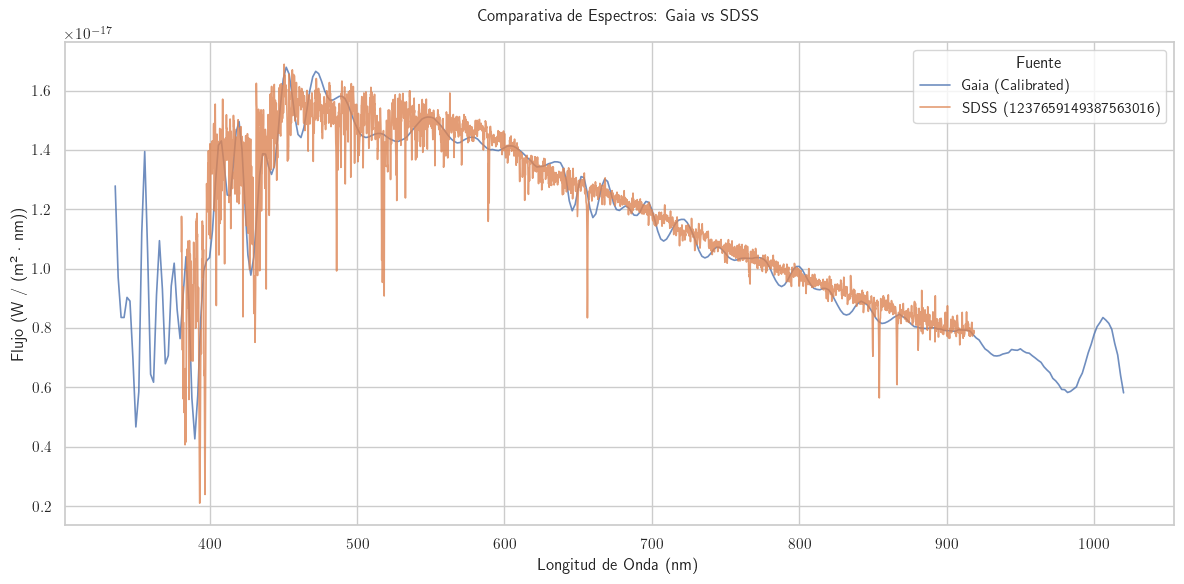

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract the arrays (same as before)
gaia_wave = gaia_object_spectrum.spectral_axis.value
gaia_flux = gaia_object_spectrum.flux.value

sdss_wave = sdss_spectrum_si.spectral_axis.value
sdss_flux = sdss_spectrum_si.flux.value

# 2. Build individual DataFrames and combine them into a "tidy" format
df_gaia = pd.DataFrame({
    "Longitud de Onda (nm)": gaia_wave,
    "Flujo (W / (m² · nm))": gaia_flux,
    "Fuente": "Gaia"
})

df_sdss = pd.DataFrame({
    "Longitud de Onda (nm)": sdss_wave,
    "Flujo (W / (m² · nm))": sdss_flux,
    "Fuente": f"SDSS"
})

df_spectra = pd.concat([df_gaia, df_sdss], ignore_index=True)

# 3. Apply a Seaborn theme for a cleaner aesthetic
sns.set_theme(style="whitegrid", palette="deep", context="notebook")

# 4. Plot declaratively 
plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=df_spectra,
    x="Longitud de Onda (nm)",
    y="Flujo (W / (m² · nm))",
    hue="Fuente",
    alpha=0.8,
    linewidth=1.2
)

ax.set_title("Comparativa de Espectros: Gaia vs SDSS", pad=15)
plt.tight_layout()
plt.show()